# SaProtΔG vs ESM3ΔG — Head-to-Head Comparison
Reads `test_set_evaluation_results.json` and compares predictions from both ensembles on the DMSv4-AF test set.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr, pearsonr

JSON_PATH = "../test_set_evaluation_results.json"

with open(JSON_PATH) as f:
    data = json.load(f)

records  = data["records"]
metrics  = data["metrics"]
df = pd.DataFrame(records)
print(f"Records: {len(df)}")
print(df.head(3))

Records: 3282
                        name   dg_true  \
0  rocklin_batch2_100004.cif  4.043921   
1  rocklin_batch2_100267.cif  0.228795   
2  rocklin_batch2_101217.cif  1.932081   

                                           sap_preds  sap_mean  \
0  [3.71262526512146, 3.7953572273254395, 3.78064...  3.762874   
1  [1.148165225982666, 1.4188767671585083, 0.3565...  0.974519   
2  [1.6452573537826538, 1.6345082521438599, 2.020...  1.766775   

                                       sap_aug_preds  sap_aug_mean  \
0  [3.8459532260894775, 3.881452798843384, 3.8463...      3.857910   
1  [1.335410714149475, 1.7154523134231567, 1.7119...      1.587590   
2  [2.229361057281494, 2.021305561065674, 1.89058...      2.047083   

                                           esm_preds  esm_mean  \
0  [4.015511512756348, 4.014668941497803, 4.20387...  4.078018   
1  [0.837997555732727, 0.7900033593177795, 0.9984...  0.875479   
2  [1.6989401578903198, 1.88588547706604, 1.82914...  1.804656   

      

In [2]:
# Overall metrics table
print(f"{'Model':<14} {'RMSE':>8} {'Spearman':>10} {'N':>6}")
print("-" * 42)
for key, label in [("saprot","SaProt"), ("saprot_aug","SaProt-Aug"), ("esm3","ESM3"), ("esm3_aug","ESM3-Aug")]:
    m = metrics[key]
    print(f"{label:<14} {m['rmse']:>8.4f} {m['spearman']:>10.4f} {m['n']:>6}")

Model              RMSE   Spearman      N
------------------------------------------
SaProt           0.8024     0.8746   3282
SaProt-Aug       0.9583     0.8364   3282
ESM3             0.8012     0.8749   3282
ESM3-Aug         0.9567     0.8093   3282


In [3]:
# Compute per-sample ensemble means
true_vals    = df["dg_true"].values
sap_mean     = df["sap_mean"].values
esm_mean     = df["esm_mean"].values
sap_aug_mean = df["sap_aug_mean"].values
esm_aug_mean = df["esm_aug_mean"].values

diff = sap_mean - esm_mean
print(f"SaProt - ESM3 difference:")
print(f"  mean  = {diff.mean():.4f} kcal/mol")
print(f"  median= {np.median(diff):.4f} kcal/mol")
print(f"  std   = {diff.std():.4f} kcal/mol")
print(f"  SaProt > ESM3 in {(diff > 0).mean()*100:.1f}% of samples")

SaProt - ESM3 difference:
  mean  = 0.1229 kcal/mol
  median= 0.1131 kcal/mol
  std   = 0.4569 kcal/mol
  SaProt > ESM3 in 61.3% of samples


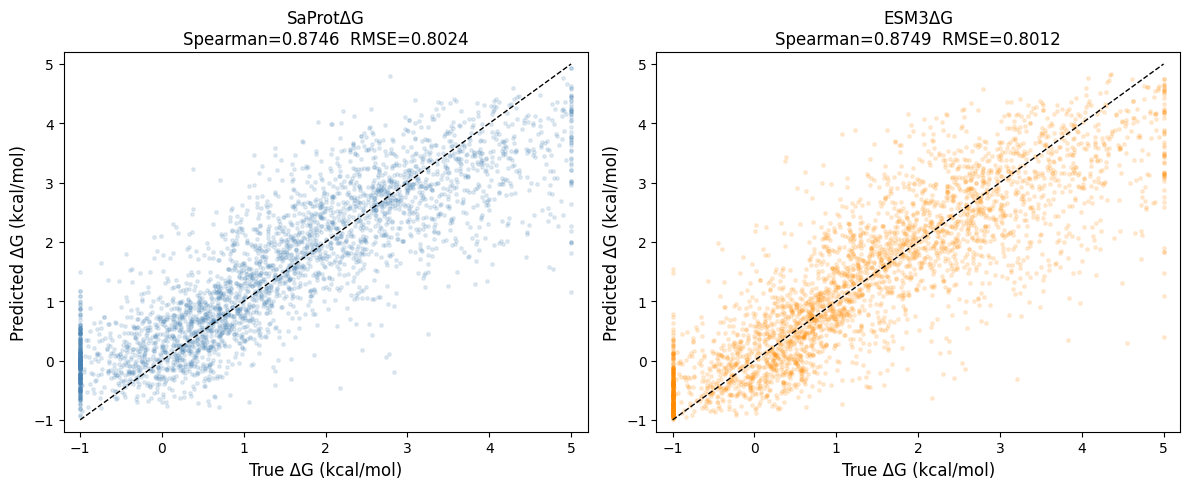

In [4]:
# ── Figure 1: Pred vs True scatter for SaProt and ESM3 side by side ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, label, color in [
    (axes[0], sap_mean, "SaProtΔG", "steelblue"),
    (axes[1], esm_mean, "ESM3ΔG",   "darkorange"),
]:
    sp = spearmanr(true_vals, pred).statistic
    rmse = np.sqrt(np.mean((true_vals - pred)**2))
    ax.scatter(true_vals, pred, alpha=0.15, s=6, color=color)
    ax.plot([-1, 5], [-1, 5], "k--", lw=1)
    ax.set_xlabel("True ΔG (kcal/mol)", fontsize=12)
    ax.set_ylabel("Predicted ΔG (kcal/mol)", fontsize=12)
    ax.set_title(f"{label}\nSpearman={sp:.4f}  RMSE={rmse:.4f}", fontsize=12)
    ax.set_xlim(-1.2, 5.2); ax.set_ylim(-1.2, 5.2)

plt.tight_layout()
plt.savefig("pred_vs_true_saprot_vs_esm3.pdf", bbox_inches="tight")
plt.show()

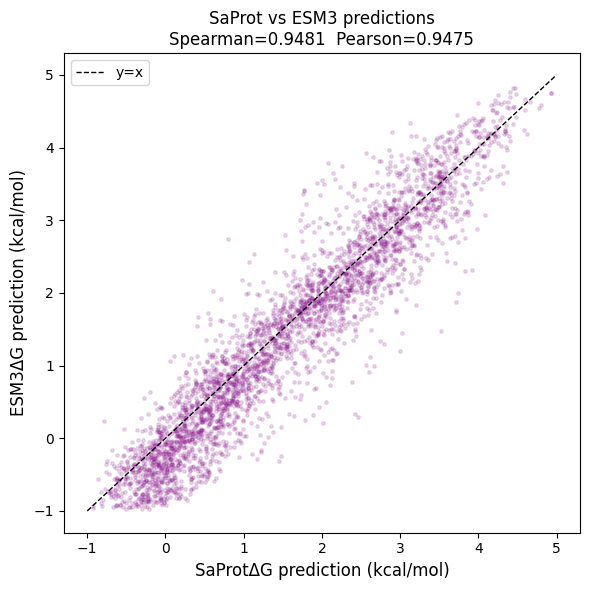

In [5]:
# ── Figure 2: SaProt vs ESM3 prediction scatter (head-to-head) ──
fig, ax = plt.subplots(figsize=(6, 6))
sp_pp = spearmanr(sap_mean, esm_mean).statistic
pr_pp = pearsonr(sap_mean, esm_mean)[0]
ax.scatter(sap_mean, esm_mean, alpha=0.15, s=6, color="purple")
ax.plot([-1, 5], [-1, 5], "k--", lw=1, label="y=x")
mn, mx = min(sap_mean.min(), esm_mean.min()), max(sap_mean.max(), esm_mean.max())
ax.set_xlabel("SaProtΔG prediction (kcal/mol)", fontsize=12)
ax.set_ylabel("ESM3ΔG prediction (kcal/mol)", fontsize=12)
ax.set_title(f"SaProt vs ESM3 predictions\nSpearman={sp_pp:.4f}  Pearson={pr_pp:.4f}", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("saprot_vs_esm3_headtohead.pdf", bbox_inches="tight")
plt.show()

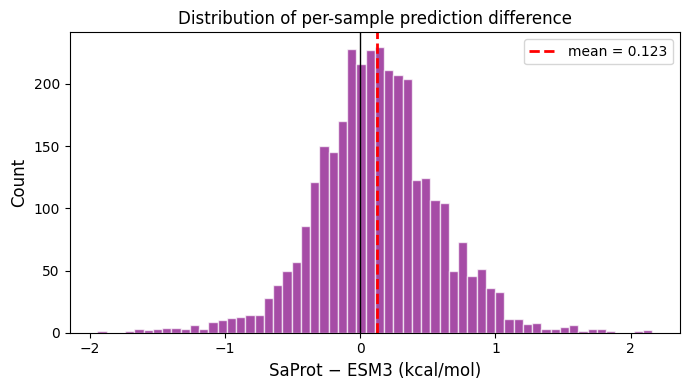

In [6]:
# ── Figure 3: Difference histogram (SaProt - ESM3) ──
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(diff, bins=60, color="purple", alpha=0.7, edgecolor="white")
ax.axvline(diff.mean(), color="red", lw=2, linestyle="--", label=f"mean = {diff.mean():.3f}")
ax.axvline(0, color="black", lw=1, linestyle="-")
ax.set_xlabel("SaProt − ESM3 (kcal/mol)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Distribution of per-sample prediction difference", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("saprot_minus_esm3_hist.pdf", bbox_inches="tight")
plt.show()

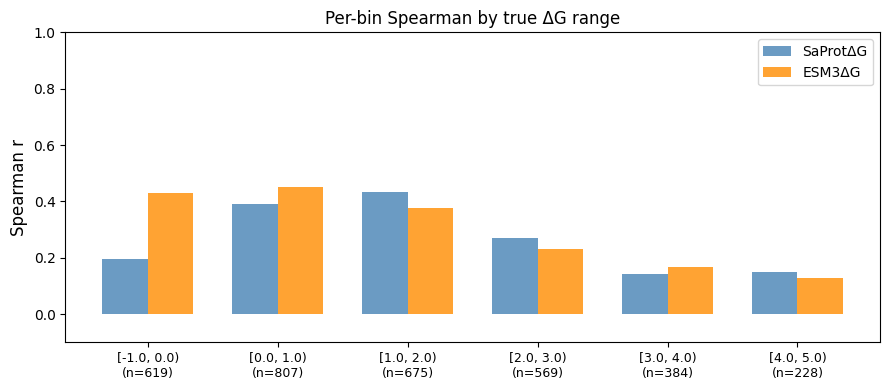

In [7]:
# ── Figure 4: Per-bin Spearman (by true ΔG range) ──
bins = np.linspace(-1, 5, 7)  # 6 bins
bin_labels = [f"[{bins[i]:.1f}, {bins[i+1]:.1f})" for i in range(len(bins)-1)]
bin_idx = np.digitize(true_vals, bins) - 1
bin_idx = np.clip(bin_idx, 0, len(bins)-2)

sap_sp_bins, esm_sp_bins, counts = [], [], []
for b in range(len(bins)-1):
    mask = bin_idx == b
    n = mask.sum()
    counts.append(n)
    if n >= 5:
        sap_sp_bins.append(spearmanr(true_vals[mask], sap_mean[mask]).statistic)
        esm_sp_bins.append(spearmanr(true_vals[mask], esm_mean[mask]).statistic)
    else:
        sap_sp_bins.append(np.nan)
        esm_sp_bins.append(np.nan)

x = np.arange(len(bin_labels))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
bars1 = ax.bar(x - w/2, sap_sp_bins, w, label="SaProtΔG", color="steelblue", alpha=0.8)
bars2 = ax.bar(x + w/2, esm_sp_bins, w, label="ESM3ΔG",   color="darkorange", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"{l}\n(n={c})" for l, c in zip(bin_labels, counts)], fontsize=9)
ax.set_ylabel("Spearman r", fontsize=12)
ax.set_title("Per-bin Spearman by true ΔG range", fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(-0.1, 1.0)
plt.tight_layout()
plt.savefig("perbin_spearman_saprot_vs_esm3.pdf", bbox_inches="tight")
plt.show()

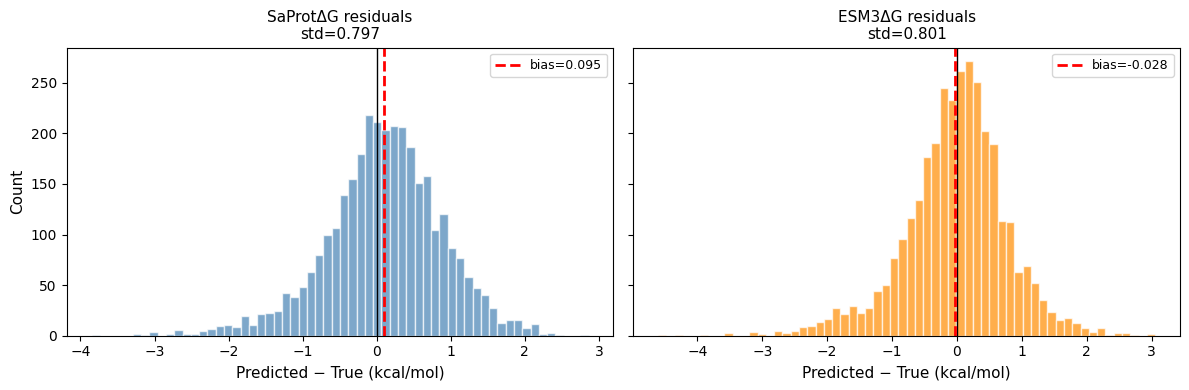

In [8]:
# ── Figure 5: Error distribution (residuals) ──
sap_err = sap_mean - true_vals
esm_err = esm_mean - true_vals

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, err, label, color in [
    (axes[0], sap_err, "SaProtΔG", "steelblue"),
    (axes[1], esm_err, "ESM3ΔG",   "darkorange"),
]:
    ax.hist(err, bins=60, color=color, alpha=0.7, edgecolor="white")
    ax.axvline(0, color="black", lw=1)
    ax.axvline(err.mean(), color="red", lw=2, linestyle="--", label=f"bias={err.mean():.3f}")
    ax.set_xlabel("Predicted − True (kcal/mol)", fontsize=11)
    ax.set_title(f"{label} residuals\nstd={err.std():.3f}", fontsize=11)
    ax.legend(fontsize=9)
axes[0].set_ylabel("Count", fontsize=11)
plt.tight_layout()
plt.savefig("residuals_saprot_vs_esm3.pdf", bbox_inches="tight")
plt.show()

In [9]:
# ── Summary table ──
print(f"{'Metric':<30} {'SaProt':>10} {'ESM3':>10}")
print("-" * 52)
print(f"{'RMSE':<30} {np.sqrt(np.mean(sap_err**2)):>10.4f} {np.sqrt(np.mean(esm_err**2)):>10.4f}")
print(f"{'Spearman':<30} {spearmanr(true_vals, sap_mean).statistic:>10.4f} {spearmanr(true_vals, esm_mean).statistic:>10.4f}")
print(f"{'Pearson':<30} {pearsonr(true_vals, sap_mean)[0]:>10.4f} {pearsonr(true_vals, esm_mean)[0]:>10.4f}")
print(f"{'Mean bias (pred-true)':<30} {sap_err.mean():>10.4f} {esm_err.mean():>10.4f}")
print(f"{'Mean pred':<30} {sap_mean.mean():>10.4f} {esm_mean.mean():>10.4f}")
print(f"{'Mean true':<30} {true_vals.mean():>10.4f}")
print(f"")
print(f"SaProt - ESM3 mean offset: {(sap_mean - esm_mean).mean():.4f} kcal/mol")
print(f"SaProt > ESM3 in {(sap_mean > esm_mean).mean()*100:.1f}% of samples")

Metric                             SaProt       ESM3
----------------------------------------------------
RMSE                               0.8024     0.8012
Spearman                           0.8746     0.8749
Pearson                            0.8619     0.8611
Mean bias (pred-true)              0.0953    -0.0277
Mean pred                          1.5568     1.4339
Mean true                          1.4615

SaProt - ESM3 mean offset: 0.1229 kcal/mol
SaProt > ESM3 in 61.3% of samples


# ThermomutDB — SaProtΔG vs ESM3ΔG Head-to-Head\nReads `final_paper_check/csv_data/thermomut_all_predictions_v2.csv`\nCompares ΔG (absolute) and ΔΔG (mutation effect) predictions for both models.

In [10]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

TM_CSV = "../final_paper_check/csv_data/thermomut_all_predictions_v2.csv"
df_tm = pd.read_csv(TM_CSV)
print(f"ThermomutDB samples: {len(df_tm)}")
print(f"Columns: {list(df_tm.columns)}")
print(df_tm[['name','experiment','experiment_dG','dG_wt',
             'predicted_SaProtdG','predicted_ESM3dG',
             'predicted_ddG_SaProtdG','predicted_ddG_ESM3dG']].head(4))

ThermomutDB samples: 1764
Columns: ['name', 'experiment', 'experiment_dG', 'dG_wt', 'mut_aa', 'wt_aa', 'position', 'paper_seq', 'GJR_trim_seq', 'PDB', 'predicted_SaProtdG', 'predicted_ddG_SaProtdG', 'predicted_SaProtdG_trim', 'predicted_ddG_SaProtdG_trim', 'predicted_Aug_SaProtdG', 'predicted_ddG_Aug_SaProtdG', 'predicted_Aug_SaProtdG_trim', 'predicted_ddG_Aug_SaProtdG_trim', 'predicted_ESM3dG', 'predicted_ddG_ESM3dG', 'predicted_ESM3dG_trim', 'predicted_ddG_ESM3dG_trim', 'predicted_Aug_ESM3dG', 'predicted_ddG_Aug_ESM3dG', 'predicted_Aug_ESM3dG_trim', 'predicted_ddG_Aug_ESM3dG_trim', 'predicted_SaProtdG_no_sigmoid', 'predicted_ddG_SaProtdG_no_sigmoid', 'predicted_ThermoMPNN']
          name  experiment  experiment_dG  dG_wt  predicted_SaProtdG  \
0  1AJ3_F1774L        -1.3            5.0    6.3            3.512077   
1  1AJ3_F1774A        -3.7            2.6    6.3            1.925682   
2  1AJ3_M1778A        -2.2            4.1    6.3            3.013001   
3  1AJ3_I1785V        -1.6 

In [11]:
# ── ΔΔG metrics (main thermomut task) ──
df_ddg = df_tm.dropna(subset=['experiment', 'predicted_ddG_SaProtdG', 'predicted_ddG_ESM3dG']).copy()

true_ddg      = df_ddg['experiment'].values
sap_ddg       = df_ddg['predicted_ddG_SaProtdG'].values
esm_ddg       = df_ddg['predicted_ddG_ESM3dG'].values
sap_aug_ddg   = df_ddg['predicted_ddG_Aug_SaProtdG'].values
esm_aug_ddg   = df_ddg['predicted_ddG_Aug_ESM3dG'].values
thermo_ddg    = df_ddg['predicted_ThermoMPNN'].values

def metrics(true, pred):
    rmse = float(np.sqrt(np.mean((true - pred)**2)))
    sp   = float(spearmanr(true, pred).statistic)
    return rmse, sp

print(f"{'Model':<22} {'RMSE':>8} {'Spearman':>10} {'N':>6}")
print("-" * 50)
for label, pred in [
    ("SaProtΔG",       sap_ddg),
    ("SaProtΔG-Aug",   sap_aug_ddg),
    ("ESM3ΔG",         esm_ddg),
    ("ESM3ΔG-Aug",     esm_aug_ddg),
    ("ThermoMPNN",     thermo_ddg),
]:
    r, sp = metrics(true_ddg, pred)
    print(f"{label:<22} {r:>8.4f} {sp:>10.4f} {len(true_ddg):>6}")

Model                      RMSE   Spearman      N
--------------------------------------------------
SaProtΔG                 1.6465     0.6432   1764
SaProtΔG-Aug             1.7557     0.6690   1764
ESM3ΔG                   1.7740     0.6620   1764
ESM3ΔG-Aug               1.7929     0.6640   1764
ThermoMPNN                  nan        nan   1764


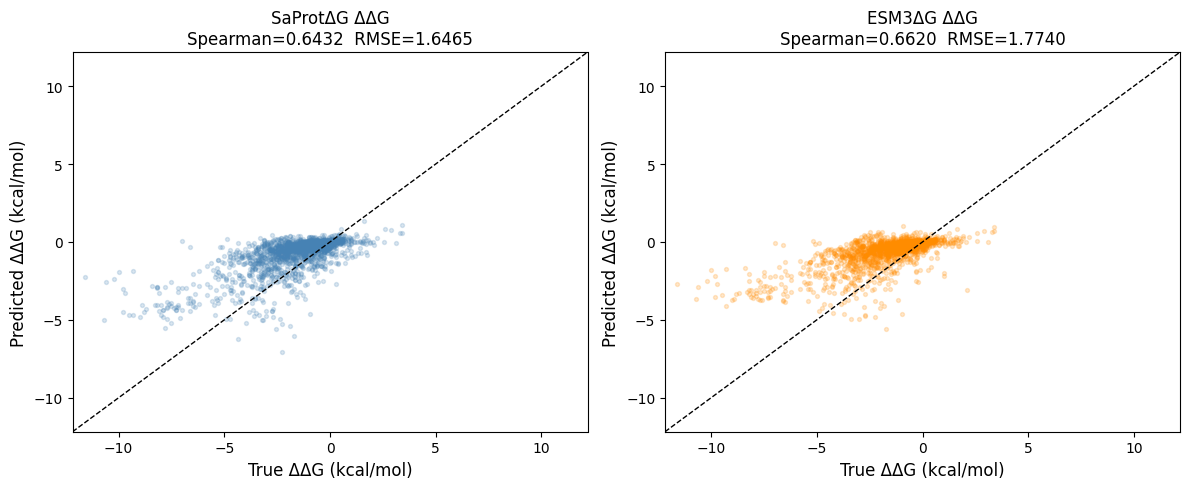

In [12]:
# ── Figure: ΔΔG pred vs true — SaProt vs ESM3 side by side ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, label, color in [
    (axes[0], sap_ddg, "SaProtΔG ΔΔG", "steelblue"),
    (axes[1], esm_ddg, "ESM3ΔG ΔΔG",   "darkorange"),
]:
    sp = spearmanr(true_ddg, pred).statistic
    rmse = np.sqrt(np.mean((true_ddg - pred)**2))
    ax.scatter(true_ddg, pred, alpha=0.2, s=8, color=color)
    lim = max(abs(true_ddg).max(), abs(pred).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], "k--", lw=1)
    ax.set_xlabel("True ΔΔG (kcal/mol)", fontsize=12)
    ax.set_ylabel("Predicted ΔΔG (kcal/mol)", fontsize=12)
    ax.set_title(f"{label}\nSpearman={sp:.4f}  RMSE={rmse:.4f}", fontsize=12)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
plt.tight_layout()
plt.savefig("thermomut_ddg_pred_vs_true.pdf", bbox_inches="tight")
plt.show()

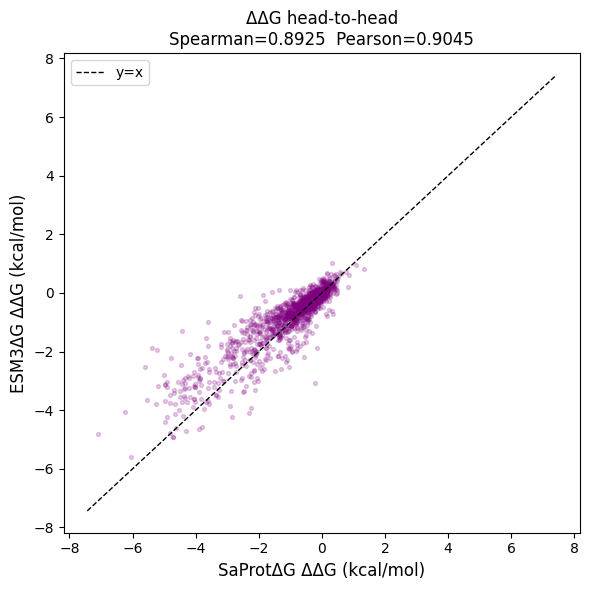

SaProt - ESM3 ΔΔG difference:  mean=-0.1650  std=0.4925


In [13]:
# ── Figure: SaProt ΔΔG vs ESM3 ΔΔG head-to-head ──
fig, ax = plt.subplots(figsize=(6, 6))
sp_pp = spearmanr(sap_ddg, esm_ddg).statistic
pr_pp = pearsonr(sap_ddg, esm_ddg)[0]
ax.scatter(sap_ddg, esm_ddg, alpha=0.2, s=8, color="purple")
lim = max(abs(sap_ddg).max(), abs(esm_ddg).max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], "k--", lw=1, label="y=x")
ax.set_xlabel("SaProtΔG ΔΔG (kcal/mol)", fontsize=12)
ax.set_ylabel("ESM3ΔG ΔΔG (kcal/mol)", fontsize=12)
ax.set_title(f"ΔΔG head-to-head\nSpearman={sp_pp:.4f}  Pearson={pr_pp:.4f}", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("thermomut_ddg_saprot_vs_esm3.pdf", bbox_inches="tight")
plt.show()

diff_ddg = sap_ddg - esm_ddg
print(f"SaProt - ESM3 ΔΔG difference:  mean={diff_ddg.mean():.4f}  std={diff_ddg.std():.4f}")

In [14]:
# ── ΔG absolute value comparison (SaProt vs ESM3 on mutant dG) ──
df_dg = df_tm.dropna(subset=['experiment_dG', 'predicted_SaProtdG', 'predicted_ESM3dG']).copy()
true_dg    = df_dg['experiment_dG'].values
sap_dg     = df_dg['predicted_SaProtdG'].values
esm_dg     = df_dg['predicted_ESM3dG'].values

print(f"ΔG absolute prediction (mutant dG, n={len(df_dg)})")
print(f"{'Model':<22} {'RMSE':>8} {'Spearman':>10} {'Mean pred':>12} {'Mean true':>12}")
print("-" * 68)
for label, pred in [("SaProtΔG", sap_dg), ("ESM3ΔG", esm_dg)]:
    r, sp = metrics(true_dg, pred)
    print(f"{label:<22} {r:>8.4f} {sp:>10.4f} {pred.mean():>12.4f} {true_dg.mean():>12.4f}")

print(f"\nSaProt - ESM3 ΔG offset:  mean={sap_dg.mean()-esm_dg.mean():.4f}  "
      f"per-sample mean={( sap_dg - esm_dg).mean():.4f}  "
      f"SaProt>ESM3 in {(sap_dg > esm_dg).mean()*100:.1f}% of samples")

ΔG absolute prediction (mutant dG, n=1764)
Model                      RMSE   Spearman    Mean pred    Mean true
--------------------------------------------------------------------
SaProtΔG                 2.3105     0.2686       4.6595       4.9442
ESM3ΔG                   2.6334     0.4733       3.3442       4.9442

SaProt - ESM3 ΔG offset:  mean=1.3153  per-sample mean=1.3153  SaProt>ESM3 in 85.0% of samples


PDBs with >=5 mutations: 35
Median per-PDB Spearman — SaProt: 0.7122  ESM3: 0.7735
SaProt > ESM3 in 45.7% of PDBs


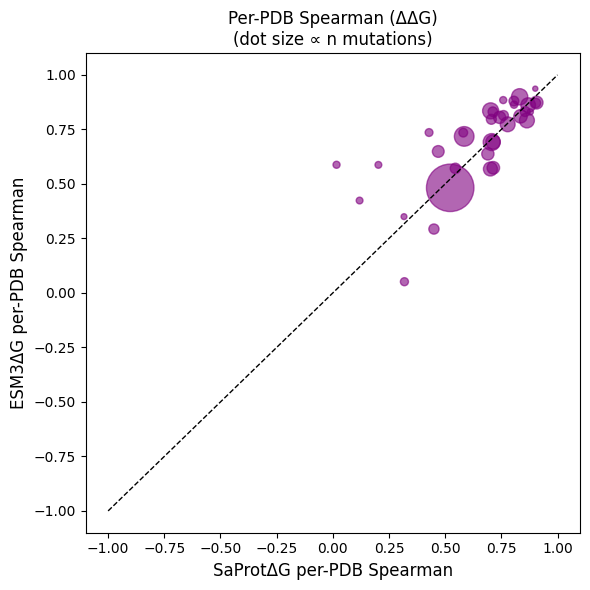

In [15]:
# ── Figure: Per-PDB Spearman (ΔΔG, by protein) ──
pdb_groups = df_ddg.groupby('PDB')
pdb_sp_sap, pdb_sp_esm, pdb_names, pdb_n = [], [], [], []
for pdb, grp in pdb_groups:
    if len(grp) < 5:
        continue
    sp_s = spearmanr(grp['experiment'], grp['predicted_ddG_SaProtdG']).statistic
    sp_e = spearmanr(grp['experiment'], grp['predicted_ddG_ESM3dG']).statistic
    pdb_sp_sap.append(sp_s)
    pdb_sp_esm.append(sp_e)
    pdb_names.append(pdb)
    pdb_n.append(len(grp))

pdb_sp_sap = np.array(pdb_sp_sap)
pdb_sp_esm = np.array(pdb_sp_esm)

print(f"PDBs with >=5 mutations: {len(pdb_names)}")
print(f"Median per-PDB Spearman — SaProt: {np.median(pdb_sp_sap):.4f}  ESM3: {np.median(pdb_sp_esm):.4f}")
print(f"SaProt > ESM3 in {(pdb_sp_sap > pdb_sp_esm).mean()*100:.1f}% of PDBs")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(pdb_sp_sap, pdb_sp_esm, s=np.array(pdb_n)*2, alpha=0.6, color="purple")
ax.plot([-1, 1], [-1, 1], "k--", lw=1)
ax.set_xlabel("SaProtΔG per-PDB Spearman", fontsize=12)
ax.set_ylabel("ESM3ΔG per-PDB Spearman", fontsize=12)
ax.set_title("Per-PDB Spearman (ΔΔG)\n(dot size ∝ n mutations)", fontsize=12)
plt.tight_layout()
plt.savefig("thermomut_perpdb_spearman.pdf", bbox_inches="tight")
plt.show()

# Spot-check: Current inference code vs saved CSV\nRuns the current `SaProtABS_predict` / `ESM3ABS_predict` on a handful of thermomut proteins\nand compares to the ensemble means already stored in `thermomut_all_predictions_v2.csv`.\nA match confirms the current code reproduces the original training-code outputs.

In [16]:
import os, sys
import torch
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

_ROOT = os.path.dirname(os.path.dirname(os.path.abspath(".")))
_ROOT = "/home/jupyter-yehlin/ESM3_SaProt_dG"
sys.path.insert(0, _ROOT)
os.chdir(_ROOT)

from utils.config import get_default_config
from utils.config_esm3 import get_default_config as get_esm3_config
from SaProtABS import SaProtABS, SaProtABS_predict
from ESM3ABS import ESM3ABS, ESM3ABS_predict

device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# Load SaProt ensemble (3 models)
sap_cfg = get_default_config()
sap_cfg.testing.ddg_scanning = False
sap_models = []
for i in [1, 2, 3]:
    w = f"{_ROOT}/saprotdg_weights/SaProtdG_weights_{i}_lora.ckpt"
    m = SaProtABS(w, sap_cfg)
    m.to(device); m.device = torch.device(device)
    sap_models.append(m)
    print(f"  SaProt model {i} loaded")

# Load ESM3 ensemble (3 non-aug models)
esm_cfg = get_esm3_config()
esm_cfg.testing.ddg_scanning = False
esm_models = []
for i in [1, 2, 3]:
    w = f"{_ROOT}/esm3dg_weights/ESM3dG_weights_{i}_lora.ckpt"
    m = ESM3ABS(w, esm_cfg)
    m.to(device); m.device = torch.device(device)
    esm_models.append(m)
    print(f"  ESM3 model {i} loaded")

/home/jupyter-yehlin/.conda/envs/esm3_attention/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda:0
Loading base SaProt model from transformers...


Some weights of EsmForMaskedLM were not initialized from the model checkpoint at westlake-repl/SaProt_650M_AF2 and are newly initialized: ['esm.contact_head.regression.bias', 'esm.contact_head.regression.weight', 'esm.embeddings.position_embeddings.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Applying LoRA to base model...
  SaProt model 1 loaded
Loading base SaProt model from transformers...


Some weights of EsmForMaskedLM were not initialized from the model checkpoint at westlake-repl/SaProt_650M_AF2 and are newly initialized: ['esm.contact_head.regression.bias', 'esm.contact_head.regression.weight', 'esm.embeddings.position_embeddings.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Applying LoRA to base model...
  SaProt model 2 loaded
Loading base SaProt model from transformers...


Some weights of EsmForMaskedLM were not initialized from the model checkpoint at westlake-repl/SaProt_650M_AF2 and are newly initialized: ['esm.contact_head.regression.bias', 'esm.contact_head.regression.weight', 'esm.embeddings.position_embeddings.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Applying LoRA to base model...
  SaProt model 3 loaded


Fetching 22 files: 100%|██████████| 22/22 [00:00<00:00, 48109.85it/s]


  ESM3 model 1 loaded
  ESM3 model 2 loaded
  ESM3 model 3 loaded


In [17]:
FULL_PDB_DIR = "/home/jupyter-yehlin/ThermoMPNN/data_all/thermomut_new/v3/full_seq_pdb"
CSV_PATH     = f"{_ROOT}/final_paper_check/csv_data/thermomut_all_predictions_v2.csv"

df_csv = pd.read_csv(CSV_PATH)
df_gt  = pd.read_csv("/home/jupyter-yehlin/ThermoMPNN/data_all/thermomut_new/v3/GJR_251121_thermomutdb_cleaned_withseq_wt.csv")

from utils.foldseek_util import get_struc_seq

SPOT_PDBS = ["1AJ3", "1CEY", "1DIV"]

def apply_mut_to_combined(wt_combined, mut_aa_seq):
    """Swap AA chars in a SaProt combined seq, keeping WT structural tokens.
    Returns None on length mismatch."""
    wt_aa = wt_combined[::2]
    if len(wt_aa) != len(mut_aa_seq):
        return None
    chars = list(wt_combined)
    for i, (w, m) in enumerate(zip(wt_aa, mut_aa_seq)):
        if w != m:
            chars[i * 2] = m
    return "".join(chars)

rows = []
for pdb in SPOT_PDBS:
    pdb_path = os.path.join(FULL_PDB_DIR, f"{pdb}.pdb")
    chain    = "A"
    gt_pdb   = df_gt[df_gt['name'].str.startswith(pdb + "_")]
    csv_pdb  = df_csv[df_csv['PDB'] == pdb]

    # Get WT SaProt combined sequence once per PDB (foldseek on WT structure)
    struct_data = get_struc_seq("bin/foldseek", pdb_path, [chain], os.getpid())
    if chain not in struct_data:
        print(f"  foldseek: chain {chain} not found in {pdb}, skipping")
        continue
    _, _, wt_combined = struct_data[chain]

    for _, row in gt_pdb.head(5).iterrows():
        name    = row['name']
        seq     = row['paper_seq']   # mutant AA sequence (plain)
        csv_row = csv_pdb[csv_pdb['name'] == name]
        if len(csv_row) == 0 or pd.isna(seq):
            continue

        csv_sap = float(csv_row['predicted_SaProtdG'].iloc[0])
        csv_esm = float(csv_row['predicted_ESM3dG'].iloc[0])

        # SaProt: graft mutant AA onto WT structural tokens
        mut_combined = apply_mut_to_combined(wt_combined, seq)
        if mut_combined is None:
            print(f"  {name}: length mismatch (foldseek={len(wt_combined)//2}, paper_seq={len(seq)}), skipping")
            continue

        sap_preds = []
        for model in sap_models:
            try:
                _, avg, _ = SaProtABS_predict(model, pdb_path, chain, given_seq=mut_combined)
                sap_preds.append(avg[0])
            except Exception as e:
                print(f"  SaProt failed {name}: {e}")
        sap_new = float(np.mean(sap_preds)) if sap_preds else np.nan

        esm_preds = []
        for model in esm_models:
            try:
                _, avg, _ = ESM3ABS_predict(model, pdb_path, chain, aa_seq=seq)
                esm_preds.append(avg[0])
            except Exception as e:
                print(f"  ESM3 failed {name}: {e}")
        esm_new = float(np.mean(esm_preds)) if esm_preds else np.nan

        rows.append({
            "name":     name,
            "sap_csv":  csv_sap,
            "sap_new":  sap_new,
            "sap_diff": abs(sap_new - csv_sap) if not np.isnan(sap_new) else np.nan,
            "esm_csv":  csv_esm,
            "esm_new":  esm_new,
            "esm_diff": abs(esm_new - csv_esm) if not np.isnan(esm_new) else np.nan,
        })

df_spot = pd.DataFrame(rows)
print(df_spot.to_string(index=False))
print(f"\nSaProt  mean|diff|={df_spot['sap_diff'].mean():.4f}  max={df_spot['sap_diff'].max():.4f}")
print(f"ESM3    mean|diff|={df_spot['esm_diff'].mean():.4f}  max={df_spot['esm_diff'].max():.4f}")

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


          name  sap_csv  sap_new     sap_diff  esm_csv  esm_new     esm_diff
   1AJ3_F1774L 3.512077 3.512077 3.178914e-07 4.076628 4.076628 0.000000e+00
   1AJ3_F1774A 1.925682 1.925682 0.000000e+00 3.240531 3.240531 0.000000e+00
   1AJ3_M1778A 3.013001 3.013001 0.000000e+00 3.766437 3.766437 0.000000e+00
   1AJ3_I1785V 3.480867 3.480867 0.000000e+00 4.004445 4.004445 0.000000e+00
   1AJ3_I1785A 3.019177 3.019177 0.000000e+00 3.644206 3.644206 0.000000e+00
1CEY_G76A_F14N 8.832869 8.832869 1.589457e-07 6.600776 6.600776 0.000000e+00
1CEY_K91G_F14N 8.327143 8.327143 0.000000e+00 6.351852 6.351852 0.000000e+00
1CEY_K91A_F14N 8.332711 8.332711 0.000000e+00 6.314272 6.314272 0.000000e+00
     1CEY_F14N 8.505643 8.505643 3.178914e-07 6.374405 6.374405 0.000000e+00
1CEY_D64G_F14N 8.595193 8.595193 3.178914e-07 6.258222 6.258222 0.000000e+00
     1DIV_L72A 3.339783 3.339783 3.178914e-07 1.693298 1.693298 2.220446e-16
     1DIV_I79A 1.208917 1.208917 0.000000e+00 1.832336 1.832336 0.000000e+00

In [22]:
df_csv.keys()

Index(['name', 'experiment', 'experiment_dG', 'dG_wt', 'mut_aa', 'wt_aa',
       'position', 'paper_seq', 'GJR_trim_seq', 'PDB', 'predicted_SaProtdG',
       'predicted_ddG_SaProtdG', 'predicted_SaProtdG_trim',
       'predicted_ddG_SaProtdG_trim', 'predicted_Aug_SaProtdG',
       'predicted_ddG_Aug_SaProtdG', 'predicted_Aug_SaProtdG_trim',
       'predicted_ddG_Aug_SaProtdG_trim', 'predicted_ESM3dG',
       'predicted_ddG_ESM3dG', 'predicted_ESM3dG_trim',
       'predicted_ddG_ESM3dG_trim', 'predicted_Aug_ESM3dG',
       'predicted_ddG_Aug_ESM3dG', 'predicted_Aug_ESM3dG_trim',
       'predicted_ddG_Aug_ESM3dG_trim', 'predicted_SaProtdG_no_sigmoid',
       'predicted_ddG_SaProtdG_no_sigmoid', 'predicted_ThermoMPNN'],
      dtype='object')

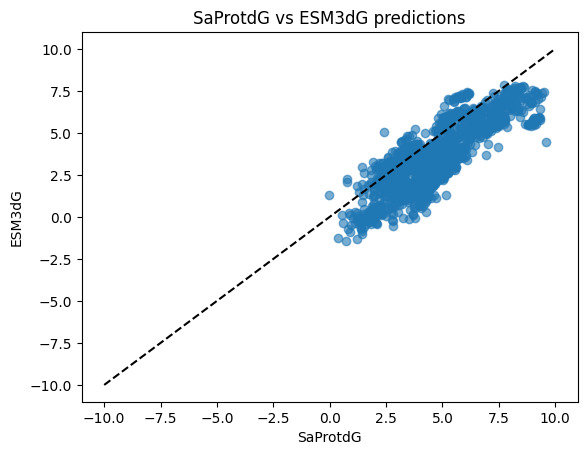

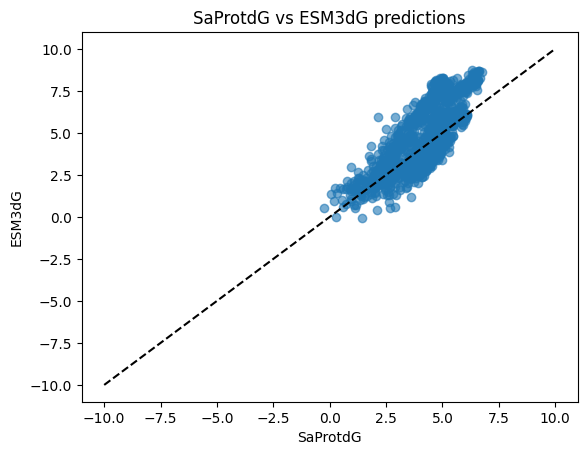

In [26]:
plt.scatter(df_csv['predicted_SaProtdG'], df_csv['predicted_ESM3dG'], alpha=0.6)
plt.xlabel('SaProtdG')
plt.ylabel('ESM3dG')
plt.plot([-10, 10], [-10, 10], 'k--')
plt.title('SaProtdG vs ESM3dG predictions')
plt.show()

plt.scatter(df_csv['predicted_Aug_SaProtdG'], df_csv['predicted_Aug_ESM3dG'],alpha=0.6)
plt.xlabel('SaProtdG')
plt.ylabel('ESM3dG')
plt.plot([-10, 10], [-10, 10], 'k--')
plt.title('SaProtdG vs ESM3dG predictions')
plt.show()

(array([1., 0., 0., 3., 2., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1.,
        0., 4., 2.]),
 array([-1.31484842, -1.13225747, -0.94966652, -0.76707556, -0.58448461,
        -0.40189366, -0.2193027 , -0.03671175,  0.14587921,  0.32847016,
         0.51106111,  0.69365207,  0.87624302,  1.05883397,  1.24142493,
         1.42401588,  1.60660683,  1.78919779,  1.97178874,  2.15437969,
         2.33697065]),
 <BarContainer object of 20 artists>)

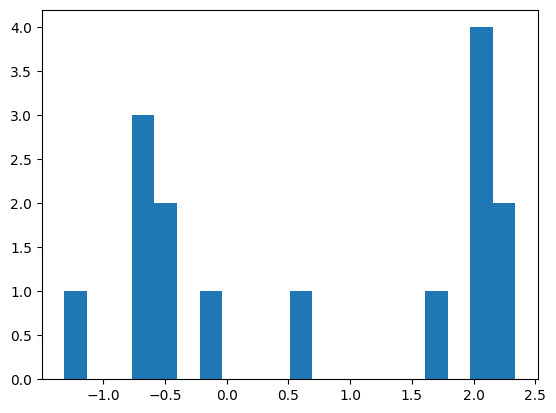

In [20]:
plt.hist(df_spot['sap_new'] - df_spot['esm_new'], bins=20)